### Explore the data from the Hierarchical brain network model

Neuron Paper, Demirtas et al., 2019

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from hbnm.io import Data
import pandas as pd
import h5py

In [2]:
# Load the data
data_handler = Data("data/", "outputs/")
hdf5_file = data_handler.load('demirtas_neuron_2019.hdf5')

In [9]:
# See what's in the root of the file
print("Root keys:", list(hdf5_file.keys()))

Root keys: ['alphabeta_removed_meg_pc1', 'apprx_posterior_heterogeneous', 'apprx_posterior_homogeneous', 'fc', 'fc_heterogeneous', 'fc_homogeneous', 'heterogeneity_maps', 'raw_meg_pc1', 'sc', 't1wt2w']


In [10]:
# Check each dataset's properties
for key in hdf5_file.keys():
    if isinstance(hdf5_file[key], h5py.Dataset):
        dset = hdf5_file[key]
        print(f"{key}: shape={dset.shape}, dtype={dset.dtype}")
        
        # Data range for numerical data
        if np.issubdtype(dset.dtype, np.number):
            data = dset[...]  # Load the data
            print(f"  Range: {data.min():.4f} to {data.max():.4f}")

alphabeta_removed_meg_pc1: shape=(360,), dtype=float64
  Range: -0.4938 to 0.9336
apprx_posterior_heterogeneous: shape=(6, 1000), dtype=float64
  Range: 0.0332 to 6.0711
apprx_posterior_homogeneous: shape=(4, 1000), dtype=float64
  Range: 1.3928 to 11.4652
fc: shape=(360, 360), dtype=float64
  Range: -0.2116 to 1.0000
fc_heterogeneous: shape=(2, 180, 180), dtype=float64
  Range: 0.0000 to 0.9066
fc_homogeneous: shape=(2, 180, 180), dtype=float64
  Range: 0.0000 to 0.8323
heterogeneity_maps: shape=(360, 10), dtype=float64
  Range: -0.0000 to 1.0000
raw_meg_pc1: shape=(360,), dtype=float64
  Range: -0.7094 to 0.7381
sc: shape=(360, 360), dtype=float64
  Range: 0.0000 to 85.8243
t1wt2w: shape=(360,), dtype=float64
  Range: 1.0899 to 1.7449


In [11]:
# Load structural connectivity
sc = hdf5_file['sc'][:]
print(f"Structural connectivity shape: {sc.shape}")
print(f"SC range: {sc.min():.4f} to {sc.max():.4f}")

# Load functional connectivity
fc = hdf5_file['fc'][:]
print(f"Functional connectivity shape: {fc.shape}")

# Load T1w/T2w heterogeneity map
t1wt2w = hdf5_file['t1wt2w'][:]
print(f"T1w/T2w map shape: {t1wt2w.shape}")
print(f"T1w/T2w range: {t1wt2w.min():.4f} to {t1wt2w.max():.4f}")


Structural connectivity shape: (360, 360)
SC range: 0.0000 to 85.8243
Functional connectivity shape: (360, 360)
T1w/T2w map shape: (360,)
T1w/T2w range: 1.0899 to 1.7449


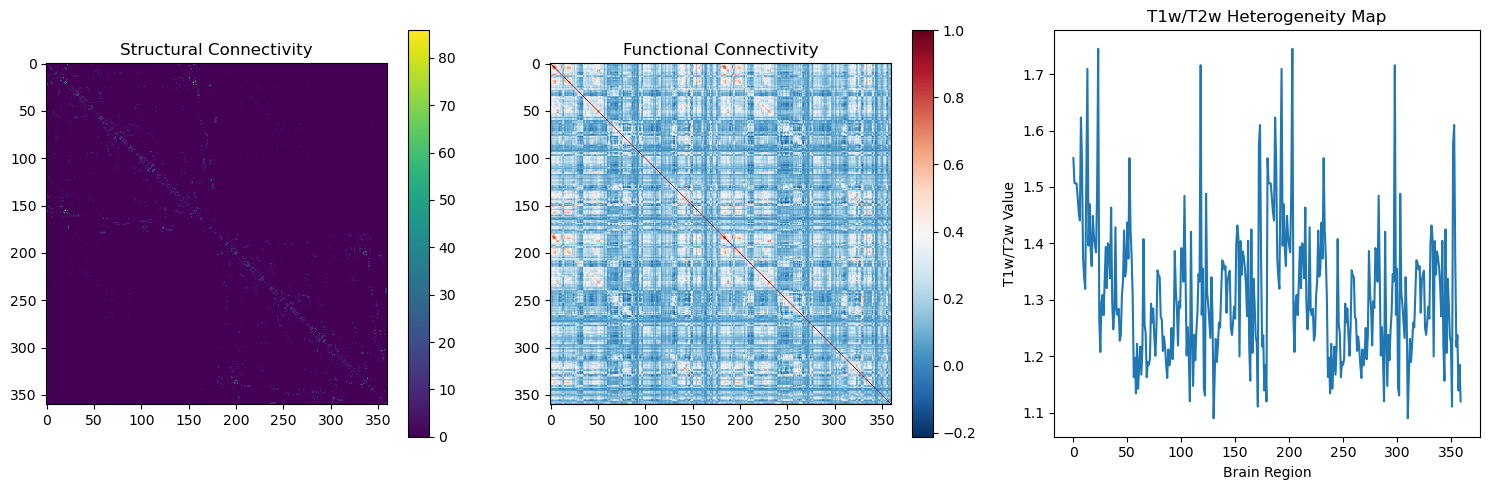

In [12]:
# Visualize the connectivity matrices
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sc, cmap='viridis')
plt.title('Structural Connectivity')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(fc, cmap='RdBu_r')
plt.title('Functional Connectivity')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.plot(t1wt2w)
plt.title('T1w/T2w Heterogeneity Map')
plt.xlabel('Brain Region')
plt.ylabel('T1w/T2w Value')

plt.tight_layout()
plt.show()